# 16. Evaluación integral cuantitativa + cualitativa interna

Este notebook integra los resultados cuantitativos y cualitativos de los 6 sistemas finales evaluados sobre la muestra representativa de 36 textos.

Los sistemas comparados son:

1. `few-shot_hariel_llama3_llama3_cfg_3_R1`
2. `few-shot_nancy_llama3_llama3_cfg_2_R2`
3. `zero-shot_hariel_llama3_hariel_llama3_cfg_1_R0`
4. `zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4`
5. `lora_llama3`
6. `lora_mistral`

La evaluación cuantitativa considera las métricas automáticas usadas en el TT:

- SARI
- BLEU
- BERTScore F1
- ROUGE-1 F1
- ROUGE-2 F1
- ROUGE-L F1
- Fernández-Huerta
- INFLESZ
- Compression ratio
- Sentence splits
- Levenshtein similarity
- Exact copy
- Additions proportion
- Deletions proportion

Además, se conserva `leader_score` como métrica líder, calculada a partir de SARI y BERTScore.

La evaluación cualitativa corresponde a la rúbrica interna aplicada manualmente a los 6 sistemas finales.

In [1]:
from pathlib import Path
import sys
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path("/home/harielpadillasanchez/Documentos/TT/TT2")

DATA_DIR = PROJECT_ROOT / "data"
CUALITATIVA_DIR = DATA_DIR / "cualitativa"
QUAL_INTERNAL_PATH = CUALITATIVA_DIR / "Evaluacion_cualitativa_interna.xlsx"

OUT_DIR = PROJECT_ROOT / "outputs" / "evaluacion_integral_lora_vs_hiperparametros"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT, "| existe:", PROJECT_ROOT.exists())
print("DATA_DIR:", DATA_DIR, "| existe:", DATA_DIR.exists())
print("CUALITATIVA_DIR:", CUALITATIVA_DIR, "| existe:", CUALITATIVA_DIR.exists())
print("QUAL_INTERNAL_PATH:", QUAL_INTERNAL_PATH, "| existe:", QUAL_INTERNAL_PATH.exists())
print("OUT_DIR:", OUT_DIR)

if not QUAL_INTERNAL_PATH.exists():
    raise FileNotFoundError(f"No existe el archivo: {QUAL_INTERNAL_PATH}")

PROJECT_ROOT: /home/harielpadillasanchez/Documentos/TT/TT2 | existe: True
DATA_DIR: /home/harielpadillasanchez/Documentos/TT/TT2/data | existe: True
CUALITATIVA_DIR: /home/harielpadillasanchez/Documentos/TT/TT2/data/cualitativa | existe: True
QUAL_INTERNAL_PATH: /home/harielpadillasanchez/Documentos/TT/TT2/data/cualitativa/Evaluacion_cualitativa_interna.xlsx | existe: True
OUT_DIR: /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_integral_lora_vs_hiperparametros


In [2]:
COMPUTE_BERTSCORE = True
# Ponderación final.
# 50/50 permite que el resultado no dependa solo de métricas automáticas.
WEIGHT_QUANT = 0.50
WEIGHT_QUAL = 0.50

assert abs(WEIGHT_QUANT + WEIGHT_QUAL - 1.0) < 1e-9

# Target usado para evaluar compression ratio.
# Un valor menor a 1 indica que el texto se redujo.
# 0.85 busca favorecer reducción moderada, sin castigar demasiado textos cercanos al original.
COMPRESSION_TARGET = 0.85

print("COMPUTE_BERTSCORE:", COMPUTE_BERTSCORE)
print("WEIGHT_QUANT:", WEIGHT_QUANT)
print("WEIGHT_QUAL:", WEIGHT_QUAL)
print("COMPRESSION_TARGET:", COMPRESSION_TARGET)

COMPUTE_BERTSCORE: True
WEIGHT_QUANT: 0.5
WEIGHT_QUAL: 0.5
COMPRESSION_TARGET: 0.85


In [3]:
# IMPORTANTE:
# Este orden debe coincidir con el orden en que están acomodados los bloques
# dentro del Excel de evaluación cualitativa interna.
#
# Prompting:
# filas 1-36   -> sistema 1
# filas 37-72  -> sistema 2
# filas 73-108 -> sistema 3
# filas 109-144 -> sistema 4
#
# LoRA:
# filas 1-36  -> lora_llama3
# filas 37-72 -> lora_mistral

PROMPTING_SYSTEM_ORDER = [
    "few-shot_hariel_llama3_llama3_cfg_3_R1",
    "few-shot_nancy_llama3_llama3_cfg_2_R2",
    "zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4",
    "zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4",
]

LORA_SYSTEM_ORDER = [
    "lora_llama3",
    "lora_mistral",
]

ALL_SYSTEM_ORDER = PROMPTING_SYSTEM_ORDER + LORA_SYSTEM_ORDER

print("Sistemas prompting:")
for i, s in enumerate(PROMPTING_SYSTEM_ORDER, start=1):
    print(i, s)

print("\nSistemas LoRA:")
for i, s in enumerate(LORA_SYSTEM_ORDER, start=1):
    print(i, s)

print("\nTotal sistemas:", len(ALL_SYSTEM_ORDER))

Sistemas prompting:
1 few-shot_hariel_llama3_llama3_cfg_3_R1
2 few-shot_nancy_llama3_llama3_cfg_2_R2
3 zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4
4 zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4

Sistemas LoRA:
1 lora_llama3
2 lora_mistral

Total sistemas: 6


In [4]:
QUANT_METRICS = [
    "sari",
    "bleu",
    "bertscore_f1",
    "rouge1_f",
    "rouge2_f",
    "rougeL_f",
    "fernandez_huerta_pred",
    "fernandez_huerta_src",
    "fernandez_huerta_delta",
    "inflesz_pred",
    "inflesz_src",
    "inflesz_delta",
    "compression_ratio_eval",
    "sentence_splits",
    "levenshtein_similarity",
    "exact_copy",
    "additions_proportion",
    "deletions_proportion",
]

LEADER_METRICS = [
    "sari",
    "bertscore_f1",
]

print("Métricas cuantitativas:")
for m in QUANT_METRICS:
    print("-", m)

Métricas cuantitativas:
- sari
- bleu
- bertscore_f1
- rouge1_f
- rouge2_f
- rougeL_f
- fernandez_huerta_pred
- fernandez_huerta_src
- fernandez_huerta_delta
- inflesz_pred
- inflesz_src
- inflesz_delta
- compression_ratio_eval
- sentence_splits
- levenshtein_similarity
- exact_copy
- additions_proportion
- deletions_proportion


In [5]:
TEXT_ID_COL = "Texto"

CRITERIA_COLS = [
    "Semántica (5|3|1)",
    "Claridad (5|3|1)",
    "Fluidez y corrección (5|3|1)",
    "Léxico y sintaxis (5|3|1)",
    "Adecuación al público / tono (5|3|1)",
    "Estructura y presentación (5|3|1)",
    "Manejo de números y datos (5|3|1)",
]

CRITERIA_RENAME = {
    "Semántica (5|3|1)": "score_fidelidad",
    "Claridad (5|3|1)": "score_comprension",
    "Fluidez y corrección (5|3|1)": "score_fluidez",
    "Léxico y sintaxis (5|3|1)": "score_lexico",
    "Adecuación al público / tono (5|3|1)": "score_tono",
    "Estructura y presentación (5|3|1)": "score_estructura",
    "Manejo de números y datos (5|3|1)": "score_numeros",
}

QUAL_SCORE_COLS = list(CRITERIA_RENAME.values())

# Pesos usados en la rúbrica.
# Estos pesos suman 100.
QUAL_WEIGHTS = {
    "score_fidelidad": 25,
    "score_comprension": 25,
    "score_fluidez": 15,
    "score_lexico": 10,
    "score_tono": 10,
    "score_estructura": 10,
    "score_numeros": 5,
}

assert sum(QUAL_WEIGHTS.values()) == 100

print("Criterios cualitativos:")
for col, weight in QUAL_WEIGHTS.items():
    print(f"{col}: {weight}%")

Criterios cualitativos:
score_fidelidad: 25%
score_comprension: 25%
score_fluidez: 15%
score_lexico: 10%
score_tono: 10%
score_estructura: 10%
score_numeros: 5%


In [6]:
xls = pd.ExcelFile(QUAL_INTERNAL_PATH)

print("Hojas disponibles:")
for i, sheet in enumerate(xls.sheet_names, start=1):
    print(f"{i}. {sheet}")

Hojas disponibles:
1. Rúbrica
2. Textos simplificados
3. Evaluación cualitativa
4. Textos simplificados Fine-tunin
5. Evaluación cualitativa fine tun


In [7]:
def normalize_text_for_match(text):
    """
    Normaliza texto para comparar coincidencias aproximadas:
    - Convierte NaN a cadena vacía.
    - Normaliza Unicode.
    - Elimina saltos de línea y espacios repetidos.
    - Pasa a minúsculas.
    """
    if pd.isna(text):
        return ""
    
    text = str(text)
    text = unicodedata.normalize("NFKC", text)
    text = text.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip().lower()
    
    return text


def preview_df(df, name="df", n=3):
    print(f"{name} shape:", df.shape)
    print(f"{name} columnas:", df.columns.tolist())
    display(df.head(n))


def clean_string_columns(df):
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].apply(lambda x: re.sub(r"\s+", " ", str(x)).strip() if not pd.isna(x) else x)
    return df

In [8]:
def read_internal_texts(path: Path, sheet_name: str) -> pd.DataFrame:
    """
    Lee una hoja de textos simplificados del Excel interno.

    Estructura esperada:
    - id
    - Texto original
    - Texto de referencia
    - Texto simplificado por el LLM
    """
    df = pd.read_excel(path, sheet_name=sheet_name)
    df = df.dropna(axis=1, how="all").copy()
    
    required_cols = [
        "id",
        "Texto original",
        "Texto de referencia",
        "Texto simplificado por el LLM",
    ]
    
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(
            f"Faltan columnas en hoja '{sheet_name}': {missing}\n"
            f"Columnas encontradas: {df.columns.tolist()}"
        )
    
    df = df[required_cols].copy()
    
    # Conservar filas con id numérico.
    df = df[pd.to_numeric(df["id"], errors="coerce").notna()].copy()
    df["id"] = pd.to_numeric(df["id"], errors="coerce").astype(int)
    
    df = df.rename(
        columns={
            "id": "texto_eval_id",
            "Texto original": "source_text",
            "Texto de referencia": "reference_text",
            "Texto simplificado por el LLM": "generated_text",
        }
    )
    
    df = clean_string_columns(df)
    
    return df.reset_index(drop=True)

In [9]:
def read_internal_scores(path: Path, sheet_name: str) -> pd.DataFrame:
    """
    Lee una hoja de evaluación cualitativa del Excel interno.

    Esta versión normaliza los nombres de columnas para evitar errores
    por dobles espacios, por ejemplo:
    'Semántica  (5|3|1)' -> 'Semántica (5|3|1)'
    """
    df = pd.read_excel(path, sheet_name=sheet_name)
    df = df.dropna(axis=1, how="all").copy()
    
    # Normalizar nombres de columnas.
    df.columns = [normalize_col_name(c) for c in df.columns]
    
    required_cols = [TEXT_ID_COL] + CRITERIA_COLS
    
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(
            f"Faltan columnas en hoja '{sheet_name}': {missing}\n"
            f"Columnas encontradas: {df.columns.tolist()}"
        )
    
    keep_cols = required_cols.copy()
    
    if "Puntaje Final" in df.columns:
        keep_cols.append("Puntaje Final")
    
    df = df[keep_cols].copy()
    
    # Quitar fila de pesos y filas vacías.
    df = df[pd.to_numeric(df[TEXT_ID_COL], errors="coerce").notna()].copy()
    df[TEXT_ID_COL] = pd.to_numeric(df[TEXT_ID_COL], errors="coerce").astype(int)
    
    df = df.rename(columns={TEXT_ID_COL: "texto_eval_id"})
    df = df.rename(columns=CRITERIA_RENAME)
    
    for col in QUAL_SCORE_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    if "Puntaje Final" in df.columns:
        df["puntaje_final_excel"] = pd.to_numeric(df["Puntaje Final"], errors="coerce")
        df = df.drop(columns=["Puntaje Final"])
    
    return df.reset_index(drop=True)

In [10]:
TEXT_ID_COL = "Texto"

# Versión normalizada de los nombres.
# Así no importa si en Excel hay uno o dos espacios.
CRITERIA_COLS = [
    "Semántica (5|3|1)",
    "Claridad (5|3|1)",
    "Fluidez y corrección (5|3|1)",
    "Léxico y sintaxis (5|3|1)",
    "Adecuación al público / tono (5|3|1)",
    "Estructura y presentación (5|3|1)",
    "Manejo de números y datos (5|3|1)",
]

CRITERIA_RENAME = {
    "Semántica (5|3|1)": "score_fidelidad",
    "Claridad (5|3|1)": "score_comprension",
    "Fluidez y corrección (5|3|1)": "score_fluidez",
    "Léxico y sintaxis (5|3|1)": "score_lexico",
    "Adecuación al público / tono (5|3|1)": "score_tono",
    "Estructura y presentación (5|3|1)": "score_estructura",
    "Manejo de números y datos (5|3|1)": "score_numeros",
}

QUAL_SCORE_COLS = list(CRITERIA_RENAME.values())

QUAL_WEIGHTS = {
    "score_fidelidad": 25,
    "score_comprension": 25,
    "score_fluidez": 15,
    "score_lexico": 10,
    "score_tono": 10,
    "score_estructura": 10,
    "score_numeros": 5,
}

assert sum(QUAL_WEIGHTS.values()) == 100

def normalize_col_name(col):
    """
    Normaliza nombres de columnas:
    - Convierte a string.
    - Reemplaza espacios múltiples por uno.
    - Quita espacios al inicio y final.
    """
    col = str(col)
    col = re.sub(r"\s+", " ", col)
    return col.strip()

print("Criterios cualitativos:")
for col, weight in QUAL_WEIGHTS.items():
    print(f"{col}: {weight}%")

Criterios cualitativos:
score_fidelidad: 25%
score_comprension: 25%
score_fluidez: 15%
score_lexico: 10%
score_tono: 10%
score_estructura: 10%
score_numeros: 5%


In [12]:
SHEET_TEXTS_PROMPT = "Textos simplificados"
SHEET_SCORES_PROMPT = "Evaluación cualitativa"

SHEET_TEXTS_LORA = "Textos simplificados Fine-tunin"
SHEET_SCORES_LORA = "Evaluación cualitativa fine tun"

texts_prompt = read_internal_texts(
    QUAL_INTERNAL_PATH,
    SHEET_TEXTS_PROMPT
)

scores_prompt = read_internal_scores(
    QUAL_INTERNAL_PATH,
    SHEET_SCORES_PROMPT
)

texts_lora = read_internal_texts(
    QUAL_INTERNAL_PATH,
    SHEET_TEXTS_LORA
)

scores_lora = read_internal_scores(
    QUAL_INTERNAL_PATH,
    SHEET_SCORES_LORA
)

preview_df(texts_prompt, "texts_prompt")
preview_df(scores_prompt, "scores_prompt")
preview_df(texts_lora, "texts_lora")
preview_df(scores_lora, "scores_lora")

texts_prompt shape: (144, 4)
texts_prompt columnas: ['texto_eval_id', 'source_text', 'reference_text', 'generated_text']


,texto_eval_id,source_text,reference_text,generated_text
0,1,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,Sin motivación y sin incentivos no se puede trabajar bien en un ambiente competitivo.
1,2,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en...",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En la importación y exportación, también participan instituciones gubernamentales y bancos, como se muestra a continuación."
2,3,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimient...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento par...","El robo de identidad es cuando alguien utiliza tu información personal, como tu nombre y números de cuenta o cédula de identidad, sin tu permiso para hacer ..."


scores_prompt shape: (144, 9)
scores_prompt columnas: ['texto_eval_id', 'score_fidelidad', 'score_comprension', 'score_fluidez', 'score_lexico', 'score_tono', 'score_estructura', 'score_numeros', 'puntaje_final_excel']


,texto_eval_id,score_fidelidad,score_comprension,score_fluidez,score_lexico,score_tono,score_estructura,score_numeros,puntaje_final_excel
0,1,3.0,5.0,5.0,5.0,5.0,5.0,5.0,4.5
1,2,3.0,5.0,5.0,5.0,5.0,5.0,5.0,4.5
2,3,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0


texts_lora shape: (72, 4)
texts_lora columnas: ['texto_eval_id', 'source_text', 'reference_text', 'generated_text']


,texto_eval_id,source_text,reference_text,generated_text
0,1,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,Sin motivación y sin incentivos no se puede trabajar bien en un ambiente competitivo.
1,2,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en...",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En la importación y exportación, también participan instituciones gubernamentales y bancos, como se muestra a continuación."
2,3,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimient...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento par...","El robo de identidad es cuando alguien utiliza tu información personal, como tu nombre y números de cuenta o cédula de identidad, sin tu permiso para hacer ..."


scores_lora shape: (73, 9)
scores_lora columnas: ['texto_eval_id', 'score_fidelidad', 'score_comprension', 'score_fluidez', 'score_lexico', 'score_tono', 'score_estructura', 'score_numeros', 'puntaje_final_excel']


,texto_eval_id,score_fidelidad,score_comprension,score_fluidez,score_lexico,score_tono,score_estructura,score_numeros,puntaje_final_excel
0,1,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
1,2,3.0,3.0,5.0,5.0,5.0,5.0,5.0,4.0
2,3,3.0,5.0,5.0,5.0,5.0,5.0,5.0,4.5


In [13]:
qual_prompt = texts_prompt.merge(
    scores_prompt,
    on="texto_eval_id",
    how="inner"
)

qual_lora = texts_lora.merge(
    scores_lora,
    on="texto_eval_id",
    how="inner"
)

print("qual_prompt shape:", qual_prompt.shape)
print("qual_lora shape:", qual_lora.shape)

display(qual_prompt.head())
display(qual_lora.head())

if len(qual_prompt) != len(texts_prompt):
    print("Ojo: no coincidieron todas las filas de prompting.")

if len(qual_lora) != len(texts_lora):
    print("Ojo: no coincidieron todas las filas de LoRA.")

qual_prompt shape: (144, 12)
qual_lora shape: (72, 12)


,texto_eval_id,source_text,reference_text,generated_text,score_fidelidad,score_comprension,score_fluidez,score_lexico,score_tono,score_estructura,score_numeros,puntaje_final_excel
0,1,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,Sin motivación y sin incentivos no se puede trabajar bien en un ambiente competitivo.,3.0,5.0,5.0,5.0,5.0,5.0,5.0,4.5
1,2,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en...",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En la importación y exportación, también participan instituciones gubernamentales y bancos, como se muestra a continuación.",3.0,5.0,5.0,5.0,5.0,5.0,5.0,4.5
2,3,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimient...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento par...","El robo de identidad es cuando alguien utiliza tu información personal, como tu nombre y números de cuenta o cédula de identidad, sin tu permiso para hacer ...",5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
3,4,"Los sueños de los niños tienen una gran variedad que va desde Tarzán hasta el Agente 007, pasando por Superman.",Los sueños de los niños son variados y van desde Tarzán hasta el Agente 007 y Superman.,"Los niños soñan con cosas como ser Tarzán, el Agente 007 o Superman.",3.0,5.0,5.0,5.0,5.0,5.0,5.0,4.5
4,5,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho se refieren a delitos vinculados a comprar la voluntad de alguien para provecho personal.,"Expresiones como ""soborno"" y ""cohecho"" se refieren a actos ilegales que involucran comprar el apoyo o consentimiento de alguien para beneficio propio.",5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0


,texto_eval_id,source_text,reference_text,generated_text,score_fidelidad,score_comprension,score_fluidez,score_lexico,score_tono,score_estructura,score_numeros,puntaje_final_excel
0,1,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,Sin motivación y sin incentivos no se puede trabajar bien en un ambiente competitivo.,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
1,2,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en...",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En la importación y exportación, también participan instituciones gubernamentales y bancos, como se muestra a continuación.",3.0,3.0,5.0,5.0,5.0,5.0,5.0,4.0
2,3,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimient...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento par...","El robo de identidad es cuando alguien utiliza tu información personal, como tu nombre y números de cuenta o cédula de identidad, sin tu permiso para hacer ...",3.0,5.0,5.0,5.0,5.0,5.0,5.0,4.5
3,4,"Los sueños de los niños tienen una gran variedad que va desde Tarzán hasta el Agente 007, pasando por Superman.",Los sueños de los niños son variados y van desde Tarzán hasta el Agente 007 y Superman.,"Los niños soñan con cosas como ser Tarzán, el Agente 007 o Superman.",5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
4,5,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho se refieren a delitos vinculados a comprar la voluntad de alguien para provecho personal.,"Expresiones como ""soborno"" y ""cohecho"" se refieren a actos ilegales que involucran comprar el apoyo o consentimiento de alguien para beneficio propio.",5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0


In [14]:
def assign_system_by_blocks(df: pd.DataFrame, system_order: list[str], block_size: int = 36) -> pd.DataFrame:
    """
    Asigna nombre de sistema suponiendo que la hoja está organizada en bloques.

    Ejemplo con block_size=36:
    filas 1-36 -> sistema 1
    filas 37-72 -> sistema 2
    etc.
    """
    out = df.copy()
    
    out["block_index"] = ((out["texto_eval_id"] - 1) // block_size).astype(int)
    
    max_block = out["block_index"].max()
    
    if max_block >= len(system_order):
        raise ValueError(
            f"Hay más bloques de los esperados. "
            f"Bloque máximo={max_block}, número de sistemas={len(system_order)}"
        )
    
    out["system_name"] = out["block_index"].apply(lambda i: system_order[i])
    out["position_in_system"] = ((out["texto_eval_id"] - 1) % block_size) + 1
    
    return out


qual_prompt = assign_system_by_blocks(
    qual_prompt,
    system_order=PROMPTING_SYSTEM_ORDER,
    block_size=36
)

qual_lora = assign_system_by_blocks(
    qual_lora,
    system_order=LORA_SYSTEM_ORDER,
    block_size=36
)

qual_prompt["system_family"] = "prompting"
qual_lora["system_family"] = "lora"

qual_detail = pd.concat([qual_prompt, qual_lora], ignore_index=True)

print("qual_detail shape:", qual_detail.shape)

display(
    qual_detail[
        [
            "texto_eval_id",
            "position_in_system",
            "system_name",
            "system_family",
            "source_text",
            "generated_text",
        ] + QUAL_SCORE_COLS
    ].head(12)
)

display(
    qual_detail[
        [
            "texto_eval_id",
            "position_in_system",
            "system_name",
            "system_family",
            "source_text",
            "generated_text",
        ] + QUAL_SCORE_COLS
    ].tail(12)
)

qual_detail shape: (216, 16)


,texto_eval_id,position_in_system,system_name,system_family,source_text,generated_text,score_fidelidad,score_comprension,score_fluidez,score_lexico,score_tono,score_estructura,score_numeros
0,1,1,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",Sin motivación y sin incentivos no se puede trabajar bien en un ambiente competitivo.,3.0,5.0,5.0,5.0,5.0,5.0,5.0
1,2,2,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en...","En la importación y exportación, también participan instituciones gubernamentales y bancos, como se muestra a continuación.",3.0,5.0,5.0,5.0,5.0,5.0,5.0
2,3,3,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimient...","El robo de identidad es cuando alguien utiliza tu información personal, como tu nombre y números de cuenta o cédula de identidad, sin tu permiso para hacer ...",5.0,5.0,5.0,5.0,5.0,5.0,5.0
3,4,4,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"Los sueños de los niños tienen una gran variedad que va desde Tarzán hasta el Agente 007, pasando por Superman.","Los niños soñan con cosas como ser Tarzán, el Agente 007 o Superman.",3.0,5.0,5.0,5.0,5.0,5.0,5.0
4,5,5,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,"Expresiones como ""soborno"" y ""cohecho"" se refieren a actos ilegales que involucran comprar el apoyo o consentimiento de alguien para beneficio propio.",5.0,5.0,5.0,5.0,5.0,5.0,5.0
5,6,6,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"DIRECCIÓN DE PRESUPUESTO (DIPRES): ""formula y lleva el control presupuestario de la nación.""",La Dirección de Presupuesto es responsable de crear y supervisar los presupuestos del país.,5.0,5.0,5.0,5.0,5.0,5.0,5.0
6,7,7,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"Interés compuesto: Es la suma del capital y el interés acumulado, que se va multiplicando según los plazos convenidos. La tasa de interés es el porcentaje q...","El interés compuesto es la suma del capital y el interés acumulado, que crece según el tiempo convenido. La tasa de interés es el porcentaje aplicado a un p...",5.0,5.0,5.0,5.0,5.0,5.0,5.0
7,8,8,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,La producción en un país se realiza mediante lo que se conoce como factores de producción y de los cuales nos ocuparemos en detalle más adelante.,"La producción en un país se hace utilizando factores como capital, trabajo y recursos naturales.",5.0,5.0,5.0,5.0,5.0,5.0,5.0
8,9,9,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"A pesar de que algunos critican al intermediario, se necesita a este individuo en la economía.","Aunque algunos lo critiquen, el intermediario es necesario en la economía.",5.0,5.0,5.0,5.0,5.0,5.0,5.0
9,10,10,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,El impuesto a los réditos es también un buen instrumento para conocer el monto de las rentas y de la riqueza nacional.,El impuesto sobre los intereses es una forma efectiva de medir el valor de las rentas y la riqueza del país.,3.0,5.0,5.0,5.0,5.0,5.0,5.0


,texto_eval_id,position_in_system,system_name,system_family,source_text,generated_text,score_fidelidad,score_comprension,score_fluidez,score_lexico,score_tono,score_estructura,score_numeros
204,61,25,lora_mistral,lora,¿Qué función cumplen las empresas en la sociedad?,"Las empresas son fundamentales para la sociedad porque crean empleos, producen bienes y servicios que mejoran nuestras vidas y generan riqueza.",1.0,1.0,5.0,5.0,5.0,5.0,5.0
205,62,26,lora_mistral,lora,Estos principios están diseñados para promover que las firmas de servicios financieros y las organizaciones de consumidores hagan más para educar a los ciud...,"Estos principios buscan fomentar la educación financiera entre los ciudadanos, logrando que las empresas de servicios financieros y las organizaciones de co...",5.0,5.0,5.0,5.0,5.0,5.0,5.0
206,63,27,lora_mistral,lora,"Hable con ellos, déles la cara, y hágales saber que está haciendo todo lo que puede para pagarles.","Hable con ellos, muéstrese dispuesto a trabajar y comuníqueles su esfuerzo por pagar.",5.0,5.0,5.0,5.0,5.0,5.0,5.0
207,64,28,lora_mistral,lora,Pero ¿en qué se compite?,"La gente se está peleando por dinero, como un carrusel que no para de girar.",1.0,1.0,5.0,5.0,5.0,5.0,5.0
208,65,29,lora_mistral,lora,"Por otra parte, algunas personas sostienen que un impuesto de 10 por ciento impondría el mismo sacrificio a ambas familias.",Algunos creen que un impuesto del 10% afectaría igualmente a ambos hogares.,5.0,5.0,5.0,5.0,5.0,5.0,3.0
209,66,30,lora_mistral,lora,"Al principio, como ya vimos en el trueque, adoptó la forma de mercancía, pero con el tiempo se transformó en dinero-papel, cuentas corrientes y otras formas.","La moneda cambió de ser un objeto físico a una representación abstracta, como billetes de papel o depósitos bancarios.",3.0,5.0,5.0,5.0,5.0,5.0,5.0
210,67,31,lora_mistral,lora,"¿Son estos sólo sueños, o son metas reales?",¿Son estas solo ilusiones o objetivos verdaderos?,5.0,5.0,5.0,5.0,5.0,5.0,5.0
211,68,32,lora_mistral,lora,"En los pueblos donde el principio de la elección se extiende a todo, no hay propiamente hablando carrera pública.","En lugares donde todos pueden elegir, no hay realmente una carrera política.",3.0,5.0,5.0,5.0,5.0,5.0,5.0
212,69,33,lora_mistral,lora,"Sin entusiasmo, dijo alguien famoso, nunca se ha podido realizar nada grande.",Nunca se logra hacer algo importante sin entusiasmo.,5.0,5.0,5.0,5.0,5.0,5.0,5.0
213,70,34,lora_mistral,lora,"Por tanto, este método calcula interés sobre interés.",Este método calcula el interés que se gana por encima del interés.,5.0,5.0,5.0,5.0,5.0,5.0,5.0


In [15]:
expected_rows = 36 * 6

print("Filas esperadas:", expected_rows)
print("Filas encontradas:", len(qual_detail))

if len(qual_detail) != expected_rows:
    print("Ojo: la cantidad de filas no es 216. Revisa el Excel o el block_size.")
else:
    print("OK: hay 216 filas, equivalentes a 36 textos x 6 sistemas.")

print("\nRegistros por sistema:")
display(
    qual_detail
    .groupby(["system_family", "system_name"], as_index=False)
    .agg(n=("texto_eval_id", "count"))
)

Filas esperadas: 216
Filas encontradas: 216
OK: hay 216 filas, equivalentes a 36 textos x 6 sistemas.

Registros por sistema:


,system_family,system_name,n
0,lora,lora_llama3,36
1,lora,lora_mistral,36
2,prompting,few-shot_hariel_llama3_llama3_cfg_3_R1,36
3,prompting,few-shot_nancy_llama3_llama3_cfg_2_R2,36
4,prompting,zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4,36
5,prompting,zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4,36


In [16]:
qual_detail["sample36_id"] = qual_detail["position_in_system"].astype(int)

display(
    qual_detail[
        [
            "sample36_id",
            "texto_eval_id",
            "system_name",
            "system_family",
            "source_text",
            "reference_text",
            "generated_text",
        ]
    ].head(10)
)

,sample36_id,texto_eval_id,system_name,system_family,source_text,reference_text,generated_text
0,1,1,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,Sin motivación y sin incentivos no se puede trabajar bien en un ambiente competitivo.
1,2,2,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en...",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En la importación y exportación, también participan instituciones gubernamentales y bancos, como se muestra a continuación."
2,3,3,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimient...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento par...","El robo de identidad es cuando alguien utiliza tu información personal, como tu nombre y números de cuenta o cédula de identidad, sin tu permiso para hacer ..."
3,4,4,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"Los sueños de los niños tienen una gran variedad que va desde Tarzán hasta el Agente 007, pasando por Superman.",Los sueños de los niños son variados y van desde Tarzán hasta el Agente 007 y Superman.,"Los niños soñan con cosas como ser Tarzán, el Agente 007 o Superman."
4,5,5,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho se refieren a delitos vinculados a comprar la voluntad de alguien para provecho personal.,"Expresiones como ""soborno"" y ""cohecho"" se refieren a actos ilegales que involucran comprar el apoyo o consentimiento de alguien para beneficio propio."
5,6,6,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"DIRECCIÓN DE PRESUPUESTO (DIPRES): ""formula y lleva el control presupuestario de la nación.""",DIRECCIÓN DE PRESUPUESTO: formula y lleva el control presupuestario de la nación.,La Dirección de Presupuesto es responsable de crear y supervisar los presupuestos del país.
6,7,7,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"Interés compuesto: Es la suma del capital y el interés acumulado, que se va multiplicando según los plazos convenidos. La tasa de interés es el porcentaje q...",El interés compuesto es la suma del capital y el interés acumulado. La tasa de interés es el porcentaje aplicado a un préstamo o inversión realizada.,"El interés compuesto es la suma del capital y el interés acumulado, que crece según el tiempo convenido. La tasa de interés es el porcentaje aplicado a un p..."
7,8,8,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,La producción en un país se realiza mediante lo que se conoce como factores de producción y de los cuales nos ocuparemos en detalle más adelante.,A través de los factores de producción se realiza la producción en un país. Más adelante nos ocuparemos en detalle de estos factores.,"La producción en un país se hace utilizando factores como capital, trabajo y recursos naturales."
8,9,9,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"A pesar de que algunos critican al intermediario, se necesita a este individuo en la economía.","Aunque algunas personas critican al intermediario, este individuo es necesario en la economía.","Aunque algunos lo critiquen, el intermediario es necesario en la economía."
9,10,10,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,El impuesto a los réditos es también un buen instrumento para conocer el

In [17]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.evaluation.metrics import evaluate_dataframe, summarize_metrics

print("Módulo src.evaluation.metrics importado correctamente.")

/home/harielpadillasanchez/Documentos/TT/TT2/.venv-bloom/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Módulo src.evaluation.metrics importado correctamente.


In [18]:
df_for_metrics = qual_detail[
    [
        "sample36_id",
        "texto_eval_id",
        "system_name",
        "system_family",
        "source_text",
        "reference_text",
        "generated_text",
    ]
].copy()

print("df_for_metrics shape:", df_for_metrics.shape)
display(df_for_metrics.head())

df_quant_detail = evaluate_dataframe(
    df_for_metrics,
    source_col="source_text",
    pred_col="generated_text",
    ref_col="reference_text",
    compute_bertscore=COMPUTE_BERTSCORE,
    compute_sbert=False,
    bertscore_lang="es",
    bertscore_model_type=None,
)

print("df_quant_detail shape:", df_quant_detail.shape)
display(df_quant_detail.head())

df_for_metrics shape: (216, 7)


,sample36_id,texto_eval_id,system_name,system_family,source_text,reference_text,generated_text
0,1,1,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,Sin motivación y sin incentivos no se puede trabajar bien en un ambiente competitivo.
1,2,2,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en...",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En la importación y exportación, también participan instituciones gubernamentales y bancos, como se muestra a continuación."
2,3,3,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimient...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento par...","El robo de identidad es cuando alguien utiliza tu información personal, como tu nombre y números de cuenta o cédula de identidad, sin tu permiso para hacer ..."
3,4,4,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"Los sueños de los niños tienen una gran variedad que va desde Tarzán hasta el Agente 007, pasando por Superman.",Los sueños de los niños son variados y van desde Tarzán hasta el Agente 007 y Superman.,"Los niños soñan con cosas como ser Tarzán, el Agente 007 o Superman."
4,5,5,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho se refieren a delitos vinculados a comprar la voluntad de alguien para provecho personal.,"Expresiones como ""soborno"" y ""cohecho"" se refieren a actos ilegales que involucran comprar el apoyo o consentimiento de alguien para beneficio propio."


df_quant_detail shape: (216, 32)


,sample36_id,texto_eval_id,system_name,system_family,source_text,reference_text,generated_text,src_words,pred_words,ref_words,src_sentences,pred_sentences,ref_sentences,sari,bleu,fernandez_huerta_pred,fernandez_huerta_src,fernandez_huerta_delta,compression_ratio_eval,sentence_splits,levenshtein_similarity,exact_copy,additions_proportion,deletions_proportion,inflesz_pred,inflesz_src,inflesz_delta,rouge1_f,rouge2_f,rougeL_f,bertscore_f1,sbert_similarity
0,1,1,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"No tiene incentivos ni motivación, dos elementos esenciales en ambientes de competencia.",No tiene sentido ni motivación. Estos elementos son esenciales para la competencia.,Sin motivación y sin incentivos no se puede trabajar bien en un ambiente competitivo.,12,14,12,1,1,2,32.203642,3.125191,75.268571,48.340000,26.928571,1.166667,0,0.485549,0,0.714286,0.666667,63.785000,39.085000,24.700000,0.214286,0.076923,0.142857,0.744898,None
1,2,2,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"En los procesos de importaciones y exportaciones intervienen, además de clientes y proveedores, instituciones del Estado y los bancos, tal como se indica en...",Clientes y proveedores intervienen en las importancias y exportaciones. También lo hacen las instituciones estatales y los banco como se indica a continuación:,"En la importación y exportación, también participan instituciones gubernamentales y bancos, como se muestra a continuación.",27,16,23,1,1,2,39.978437,4.965502,46.715000,69.728889,-23.013889,0.592593,0,0.516556,0,0.562500,0.740741,31.191250,41.390556,-10.199306,0.488889,0.186047,0.488889,0.814797,None
2,3,3,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"El robo de identidad ocurre cuando su información personal, tal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimient...","El robo de identidad ocurre cuando su información personal como su nombre, número de cuenta, o número de cédula de identidad se usan sin su conocimiento par...","El robo de identidad es cuando alguien utiliza tu información personal, como tu nombre y números de cuenta o cédula de identidad, sin tu permiso para hacer ...",33,29,32,1,1,1,17.341470,13.523512,72.977931,81.930909,-8.952978,0.878788,0,0.717391,0,0.413793,0.484848,42.493621,47.347121,-4.853501,0.588235,0.333333,0.588235,0.854182,None
3,4,4,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,"Los sueños de los niños tienen una gran variedad que va desde Tarzán hasta el Agente 007, pasando por Superman.",Los sueños de los niños son variados y van desde Tarzán hasta el Agente 007 y Superman.,"Los niños soñan con cosas como ser Tarzán, el Agente 007 o Superman.",20,13,17,1,1,1,39.355610,11.326623,102.070769,99.740000,2.330769,0.650000,0,0.536313,0,0.461538,0.650000,93.196538,80.925000,12.271538,0.500000,0.294118,0.500000,0.842181,None
4,5,5,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,Expresiones como soborno y cohecho se refieren a ilícitos vinculados a la compra de la voluntad de un individuo para provecho personal.,Expresiones como soborno y cohecho se refieren a delitos vinculados a comprar la voluntad de alguien para provecho personal.,"Expresiones como ""soborno"" y ""cohecho"" se refieren a actos ilegales que involucran comprar el apoyo o consentimiento de alguien para beneficio propio.",22,22,19,1,1,1,39.102538,11.145672,60.385455,68.567273,-8.181818,1.000000,0,0.582456,0,0.545455,0.545455,37.580455,46.075909,-8.495455,0.585366,0.461538,0.585366,0.895930,None


In [19]:
available_metrics = []
missing_metrics = []

for metric in QUANT_METRICS:
    if metric in df_quant_detail.columns and df_quant_detail[metric].notna().any():
        available_metrics.append(metric)
    else:
        missing_metrics.append(metric)

print("Métricas disponibles:")
for m in available_metrics:
    print("-", m)

print("\nMétricas NO disponibles:")
for m in missing_metrics:
    print("-", m)

if missing_metrics:
    print("\nSi faltan BLEU o ROUGE, ejecuta la celda de instalación y vuelve a correr desde la importación de métricas.")
    print("Si falta BERTScore, verifica que bert-score esté instalado o cambia COMPUTE_BERTSCORE.")

Métricas disponibles:
- sari
- bleu
- bertscore_f1
- rouge1_f
- rouge2_f
- rougeL_f
- fernandez_huerta_pred
- fernandez_huerta_src
- fernandez_huerta_delta
- inflesz_pred
- inflesz_src
- inflesz_delta
- compression_ratio_eval
- sentence_splits
- levenshtein_similarity
- exact_copy
- additions_proportion
- deletions_proportion

Métricas NO disponibles:


In [20]:
for col in QUAL_SCORE_COLS:
    qual_detail[col] = pd.to_numeric(qual_detail[col], errors="coerce")

print("Valores faltantes por criterio:")
display(qual_detail[QUAL_SCORE_COLS].isna().sum())

rows_missing = qual_detail[qual_detail[QUAL_SCORE_COLS].isna().any(axis=1)]

print("Filas con algún criterio faltante:", len(rows_missing))

if len(rows_missing) > 0:
    display(
        rows_missing[
            [
                "texto_eval_id",
                "sample36_id",
                "system_name",
            ] + QUAL_SCORE_COLS
        ].head(20)
    )

Valores faltantes por criterio:


score_fidelidad      0
score_comprension    0
score_fluidez        0
score_lexico         0
score_tono           0
score_estructura     0
score_numeros        0
dtype: int64

Filas con algún criterio faltante: 0


In [21]:
qual_detail["aplico_regla_cero"] = (qual_detail[QUAL_SCORE_COLS] == 0).any(axis=1)

weight_sum = sum(QUAL_WEIGHTS.values())

qual_detail["score_cualitativo_1_5_sin_regla_cero"] = 0.0

for col, weight in QUAL_WEIGHTS.items():
    qual_detail["score_cualitativo_1_5_sin_regla_cero"] += (
        qual_detail[col] * (weight / weight_sum)
    )

qual_detail["score_cualitativo_1_5"] = np.where(
    qual_detail["aplico_regla_cero"],
    0.0,
    qual_detail["score_cualitativo_1_5_sin_regla_cero"]
)

qual_detail["score_cualitativo_100"] = (qual_detail["score_cualitativo_1_5"] / 5.0) * 100.0

display(
    qual_detail[
        [
            "sample36_id",
            "texto_eval_id",
            "system_name",
            "aplico_regla_cero",
            "score_cualitativo_1_5",
            "score_cualitativo_100",
        ] + QUAL_SCORE_COLS
    ].head(15)
)

,sample36_id,texto_eval_id,system_name,aplico_regla_cero,score_cualitativo_1_5,score_cualitativo_100,score_fidelidad,score_comprension,score_fluidez,score_lexico,score_tono,score_estructura,score_numeros
0,1,1,few-shot_hariel_llama3_llama3_cfg_3_R1,False,4.5,90.0,3.0,5.0,5.0,5.0,5.0,5.0,5.0
1,2,2,few-shot_hariel_llama3_llama3_cfg_3_R1,False,4.5,90.0,3.0,5.0,5.0,5.0,5.0,5.0,5.0
2,3,3,few-shot_hariel_llama3_llama3_cfg_3_R1,False,5.0,100.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
3,4,4,few-shot_hariel_llama3_llama3_cfg_3_R1,False,4.5,90.0,3.0,5.0,5.0,5.0,5.0,5.0,5.0
4,5,5,few-shot_hariel_llama3_llama3_cfg_3_R1,False,5.0,100.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
5,6,6,few-shot_hariel_llama3_llama3_cfg_3_R1,False,5.0,100.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
6,7,7,few-shot_hariel_llama3_llama3_cfg_3_R1,False,5.0,100.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
7,8,8,few-shot_hariel_llama3_llama3_cfg_3_R1,False,5.0,100.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
8,9,9,few-shot_hariel_llama3_llama3_cfg_3_R1,False,5.0,100.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
9,10,10,few-shot_hariel_llama3_llama3_cfg_3_R1,False,4.5,90.0,3.0,5.0,5.0,5.0,5.0,5.0,5.0


In [22]:
qual_summary = (
    qual_detail
    .groupby(["system_name", "system_family"], as_index=False)
    .agg(
        n_textos_cualitativos=("sample36_id", "count"),
        score_cualitativo_promedio_1_5=("score_cualitativo_1_5", "mean"),
        score_cualitativo_mediano_1_5=("score_cualitativo_1_5", "median"),
        score_cualitativo_min_1_5=("score_cualitativo_1_5", "min"),
        score_cualitativo_max_1_5=("score_cualitativo_1_5", "max"),
        score_cualitativo_promedio_100=("score_cualitativo_100", "mean"),
        textos_con_regla_cero=("aplico_regla_cero", "sum"),
        promedio_fidelidad=("score_fidelidad", "mean"),
        promedio_comprension=("score_comprension", "mean"),
        promedio_fluidez=("score_fluidez", "mean"),
        promedio_lexico=("score_lexico", "mean"),
        promedio_tono=("score_tono", "mean"),
        promedio_estructura=("score_estructura", "mean"),
        promedio_numeros=("score_numeros", "mean"),
    )
)

qual_summary = qual_summary.sort_values(
    "score_cualitativo_promedio_100",
    ascending=False
).reset_index(drop=True)

qual_summary["rank_cualitativo"] = np.arange(1, len(qual_summary) + 1)

display(qual_summary)

,system_name,system_family,n_textos_cualitativos,score_cualitativo_promedio_1_5,score_cualitativo_mediano_1_5,score_cualitativo_min_1_5,score_cualitativo_max_1_5,score_cualitativo_promedio_100,textos_con_regla_cero,promedio_fidelidad,promedio_comprension,promedio_fluidez,promedio_lexico,promedio_tono,promedio_estructura,promedio_numeros,rank_cualitativo
0,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,36,4.597222,5.00,3.0,5.0,91.944444,0,3.833333,4.611111,4.944444,5.000000,5.000000,5.000000,4.888889,1
1,lora_mistral,lora,36,4.586111,4.90,2.7,5.0,91.722222,0,3.888889,4.611111,4.888889,4.888889,5.000000,5.000000,4.777778,2
2,lora_llama3,lora,36,4.563889,4.70,3.0,5.0,91.277778,0,3.888889,4.555556,4.944444,4.944444,4.944444,4.944444,4.555556,3
3,few-shot_nancy_llama3_llama3_cfg_2_R2,prompting,36,4.505556,4.90,2.6,5.0,90.111111,0,3.944444,4.333333,4.944444,4.833333,5.000000,4.888889,4.444444,4
4,zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4,prompting,36,3.866667,4.20,0.0,5.0,77.333333,4,4.000000,3.166667,3.722222,4.277778,4.444444,4.333333,4.222222,5
5,zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4,prompting,36,3.736111,4.05,0.0,5.0,74.722222,5,3.361111,3.416667,3.861111,4.027778,4.305556,4.250000,4.083333,6


In [23]:
def mean_numeric(series):
    series = pd.to_numeric(series, errors="coerce")
    if series.notna().any():
        return series.mean()
    return np.nan


quant_summary = (
    df_quant_detail
    .groupby(["system_name", "system_family"], as_index=False)
    .agg(
        n_textos=("sample36_id", "count"),
        **{metric: (metric, mean_numeric) for metric in QUANT_METRICS}
    )
)

# Leader score:
# 60% SARI + 40% BERTScore_F1 en escala 0-100.
# Si BERTScore no existe, se usa solo SARI para evitar NaN.
if "bertscore_f1" in quant_summary.columns and quant_summary["bertscore_f1"].notna().any():
    quant_summary["leader_score"] = (
        0.60 * quant_summary["sari"] +
        0.40 * (quant_summary["bertscore_f1"] * 100.0)
    )
else:
    quant_summary["leader_score"] = quant_summary["sari"]

quant_summary = quant_summary.sort_values(
    ["leader_score", "sari"],
    ascending=False
).reset_index(drop=True)

quant_summary["rank_leader_score"] = np.arange(1, len(quant_summary) + 1)

display(quant_summary)

,system_name,system_family,n_textos,sari,bleu,bertscore_f1,rouge1_f,rouge2_f,rougeL_f,fernandez_huerta_pred,fernandez_huerta_src,fernandez_huerta_delta,inflesz_pred,inflesz_src,inflesz_delta,compression_ratio_eval,sentence_splits,levenshtein_similarity,exact_copy,additions_proportion,deletions_proportion,leader_score,rank_leader_score
0,zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4,prompting,36,36.889493,13.618780,0.793498,0.427987,0.228261,0.373693,73.975601,81.010563,-7.034962,64.159996,59.599136,4.560859,1.200421,0.750000,0.436021,0.0,0.567748,0.563793,53.873632,1
1,few-shot_nancy_llama3_llama3_cfg_2_R2,prompting,36,35.376242,13.077614,0.808004,0.420103,0.221107,0.371417,73.498114,81.010563,-7.512449,60.521654,59.599136,0.922518,0.914333,0.083333,0.470420,0.0,0.528829,0.626821,53.545895,2
2,lora_mistral,lora,36,35.330991,12.944911,0.808024,0.420103,0.217523,0.369734,73.498114,81.010563,-7.512449,60.521654,59.599136,0.922518,0.914333,0.083333,0.470122,0.0,0.531144,0.628209,53.519540,3
3,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,36,34.720050,12.621101,0.807067,0.409761,0.218861,0.376495,71.983624,81.010563,-9.026939,59.856422,59.599136,0.257286,1.062598,0.166667,0.468635,0.0,0.549375,0.645109,53.114721,4
4,lora_llama3,lora,36,34.720050,12.621101,0.807067,0.409761,0.218861,0.376495,71.983624,81.010563,-9.026939,59.856422,59.599136,0.257286,1.062598,0.166667,0.468635,0.0,0.549375,0.645109,53.114721,5
5,zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4,prompting,36,34.354454,10.494575,0.785960,0.401170,0.189632,0.359806,76.329574,81.010563,-4.680989,66.617159,59.599136,7.018022,1.111977,0.638889,0.409169,0.0,0.577812,0.588345,52.051082,6


In [24]:
# Métricas donde más alto es mejor.
HIGHER_IS_BETTER = [
    "sari",
    "bleu",
    "bertscore_f1",
    "rouge1_f",
    "rouge2_f",
    "rougeL_f",
    "fernandez_huerta_pred",
    "inflesz_pred",
]

# Métricas donde más bajo es mejor.
LOWER_IS_BETTER = [
    "exact_copy",
]

# Métricas donde se busca cercanía a un valor objetivo.
TARGET_IS_BETTER = {
    "compression_ratio_eval": COMPRESSION_TARGET,
}

# Métricas que se reportan, pero no entran directamente al score integral
# porque su interpretación depende del caso.
DESCRIPTIVE_ONLY = [
    "fernandez_huerta_src",
    "fernandez_huerta_delta",
    "inflesz_src",
    "inflesz_delta",
    "sentence_splits",
    "levenshtein_similarity",
    "additions_proportion",
    "deletions_proportion",
]


def minmax_normalize(series: pd.Series, higher_is_better=True):
    s = pd.to_numeric(series, errors="coerce")
    
    if not s.notna().any():
        return pd.Series(np.nan, index=s.index)
    
    min_val = s.min()
    max_val = s.max()
    
    if np.isclose(min_val, max_val):
        return pd.Series(1.0, index=s.index)
    
    norm = (s - min_val) / (max_val - min_val)
    
    if not higher_is_better:
        norm = 1 - norm
    
    return norm


def target_normalize(series: pd.Series, target: float):
    s = pd.to_numeric(series, errors="coerce")
    
    if not s.notna().any():
        return pd.Series(np.nan, index=s.index)
    
    distance = (s - target).abs()
    return minmax_normalize(distance, higher_is_better=False)

In [25]:
quant_norm = quant_summary.copy()

norm_cols = []

for metric in HIGHER_IS_BETTER:
    if metric in quant_norm.columns and quant_norm[metric].notna().any():
        col = f"norm_{metric}"
        quant_norm[col] = minmax_normalize(quant_norm[metric], higher_is_better=True)
        norm_cols.append(col)

for metric in LOWER_IS_BETTER:
    if metric in quant_norm.columns and quant_norm[metric].notna().any():
        col = f"norm_{metric}"
        quant_norm[col] = minmax_normalize(quant_norm[metric], higher_is_better=False)
        norm_cols.append(col)

for metric, target in TARGET_IS_BETTER.items():
    if metric in quant_norm.columns and quant_norm[metric].notna().any():
        col = f"norm_{metric}"
        quant_norm[col] = target_normalize(quant_norm[metric], target=target)
        norm_cols.append(col)

quant_norm["norm_leader_score"] = minmax_normalize(
    quant_norm["leader_score"],
    higher_is_better=True
)

# Promedio de métricas auxiliares.
aux_norm_cols = norm_cols.copy()

quant_norm["aux_quant_score"] = quant_norm[aux_norm_cols].mean(axis=1, skipna=True)

# Score cuantitativo integral:
# 50% leader score normalizado + 50% resto de métricas normalizadas.
quant_norm["score_cuantitativo_integral_100"] = (
    0.50 * quant_norm["norm_leader_score"] +
    0.50 * quant_norm["aux_quant_score"]
) * 100

quant_score_df = quant_norm.sort_values(
    "score_cuantitativo_integral_100",
    ascending=False
).reset_index(drop=True)

quant_score_df["rank_cuantitativo_integral"] = np.arange(1, len(quant_score_df) + 1)

print("Métricas normalizadas usadas para el score cuantitativo:")
for c in aux_norm_cols:
    print("-", c)

display(
    quant_score_df[
        [
            "system_name",
            "system_family",
            "n_textos",
            "leader_score",
            "score_cuantitativo_integral_100",
            "rank_cuantitativo_integral",
        ] + QUANT_METRICS
    ]
)

Métricas normalizadas usadas para el score cuantitativo:
- norm_sari
- norm_bleu
- norm_bertscore_f1
- norm_rouge1_f
- norm_rouge2_f
- norm_rougeL_f
- norm_fernandez_huerta_pred
- norm_inflesz_pred
- norm_exact_copy
- norm_compression_ratio_eval


,system_name,system_family,n_textos,leader_score,score_cuantitativo_integral_100,rank_cuantitativo_integral,sari,bleu,bertscore_f1,rouge1_f,rouge2_f,rougeL_f,fernandez_huerta_pred,fernandez_huerta_src,fernandez_huerta_delta,inflesz_pred,inflesz_src,inflesz_delta,compression_ratio_eval,sentence_splits,levenshtein_similarity,exact_copy,additions_proportion,deletions_proportion
0,zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4,prompting,36,53.873632,86.343421,1,36.889493,13.618780,0.793498,0.427987,0.228261,0.373693,73.975601,81.010563,-7.034962,64.159996,59.599136,4.560859,1.200421,0.750000,0.436021,0.0,0.567748,0.563793
1,few-shot_nancy_llama3_llama3_cfg_2_R2,prompting,36,53.545895,75.470622,2,35.376242,13.077614,0.808004,0.420103,0.221107,0.371417,73.498114,81.010563,-7.512449,60.521654,59.599136,0.922518,0.914333,0.083333,0.470420,0.0,0.528829,0.626821
2,lora_mistral,lora,36,53.519540,73.482172,3,35.330991,12.944911,0.808024,0.420103,0.217523,0.369734,73.498114,81.010563,-7.512449,60.521654,59.599136,0.922518,0.914333,0.083333,0.470122,0.0,0.531144,0.628209
3,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,36,53.114721,55.881583,4,34.720050,12.621101,0.807067,0.409761,0.218861,0.376495,71.983624,81.010563,-9.026939,59.856422,59.599136,0.257286,1.062598,0.166667,0.468635,0.0,0.549375,0.645109
4,lora_llama3,lora,36,53.114721,55.881583,5,34.720050,12.621101,0.807067,0.409761,0.218861,0.376495,71.983624,81.010563,-9.026939,59.856422,59.599136,0.257286,1.062598,0.166667,0.468635,0.0,0.549375,0.645109
5,zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4,prompting,36,52.051082,16.545751,6,34.354454,10.494575,0.785960,0.401170,0.189632,0.359806,76.329574,81.010563,-4.680989,66.617159,59.599136,7.018022,1.111977,0.638889,0.409169,0.0,0.577812,0.588345


In [26]:
integral_df = quant_score_df.merge(
    qual_summary,
    on=["system_name", "system_family"],
    how="left"
)

missing_qual = integral_df[integral_df["score_cualitativo_promedio_100"].isna()]

print("integral_df shape:", integral_df.shape)

if len(missing_qual) > 0:
    print("Sistemas sin evaluación cualitativa:")
    display(missing_qual[["system_name", "system_family"]])
else:
    print("OK: todos los sistemas tienen evaluación cualitativa.")

display(integral_df.head())

integral_df shape: (6, 52)
OK: todos los sistemas tienen evaluación cualitativa.


,system_name,system_family,n_textos,sari,bleu,bertscore_f1,rouge1_f,rouge2_f,rougeL_f,fernandez_huerta_pred,fernandez_huerta_src,fernandez_huerta_delta,inflesz_pred,inflesz_src,inflesz_delta,compression_ratio_eval,sentence_splits,levenshtein_similarity,exact_copy,additions_proportion,deletions_proportion,leader_score,rank_leader_score,norm_sari,norm_bleu,norm_bertscore_f1,norm_rouge1_f,norm_rouge2_f,norm_rougeL_f,norm_fernandez_huerta_pred,norm_inflesz_pred,norm_exact_copy,norm_compression_ratio_eval,norm_leader_score,aux_quant_score,score_cuantitativo_integral_100,rank_cuantitativo_integral,n_textos_cualitativos,score_cualitativo_promedio_1_5,score_cualitativo_mediano_1_5,score_cualitativo_min_1_5,score_cualitativo_max_1_5,score_cualitativo_promedio_100,textos_con_regla_cero,promedio_fidelidad,promedio_comprension,promedio_fluidez,promedio_lexico,promedio_tono,promedio_estructura,promedio_numeros,rank_cualitativo
0,zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4,prompting,36,36.889493,13.618780,0.793498,0.427987,0.228261,0.373693,73.975601,81.010563,-7.034962,64.159996,59.599136,4.560859,1.200421,0.750000,0.436021,0.0,0.567748,0.563793,53.873632,1,1.000000,1.000000,0.341659,1.000000,1.000000,0.832118,0.458353,0.636554,1.0,0.000000,1.000000,0.726868,86.343421,1,36,3.736111,4.05,0.0,5.0,74.722222,5,3.361111,3.416667,3.861111,4.027778,4.305556,4.250000,4.083333,6
1,few-shot_nancy_llama3_llama3_cfg_2_R2,prompting,36,35.376242,13.077614,0.808004,0.420103,0.221107,0.371417,73.498114,81.010563,-7.512449,60.521654,59.599136,0.922518,0.914333,0.083333,0.470420,0.0,0.528829,0.626821,53.545895,2,0.403066,0.826783,0.999098,0.706007,0.814795,0.695732,0.348483,0.098396,1.0,1.000000,0.820176,0.689236,75.470622,2,36,4.505556,4.90,2.6,5.0,90.111111,0,3.944444,4.333333,4.944444,4.833333,5.000000,4.888889,4.444444,4
2,lora_mistral,lora,36,35.330991,12.944911,0.808024,0.420103,0.217523,0.369734,73.498114,81.010563,-7.512449,60.521654,59.599136,0.922518,0.914333,0.083333,0.470122,0.0,0.531144,0.628209,53.519540,3,0.385216,0.784307,1.000000,0.706007,0.722011,0.594855,0.348483,0.098396,1.0,1.000000,0.805716,0.663928,73.482172,3,36,4.586111,4.90,2.7,5.0,91.722222,0,3.888889,4.611111,4.888889,4.888889,5.000000,5.000000,4.777778,2
3,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,36,34.720050,12.621101,0.807067,0.409761,0.218861,0.376495,71.983624,81.010563,-9.026939,59.856422,59.599136,0.257286,1.062598,0.166667,0.468635,0.0,0.549375,0.645109,53.114721,4,0.144217,0.680662,0.956654,0.320375,0.756665,1.000000,0.000000,0.000000,1.0,0.481752,0.583599,0.534033,55.881583,4,36,4.597222,5.00,3.0,5.0,91.944444,0,3.833333,4.611111,4.944444,5.000000,5.000000,5.000000,4.888889,1
4,lora_llama3,lora,36,34.720050,12.621101,0.807067,0.409761,0.218861,0.376495,71.983624,81.010563,-9.026939,59.856422,59.599136,0.257286,1.062598,0.166667,0.468635,0.0,0.549375,0.645109,53.114721,5,0.144217,0.680662,0.956654,0.320375,0.756665,1.000000,0.000000,0.000000,1.0,0.481752,0.583599,0.534033,55.881583,5,36,4.563889,4.70,3.0,5.0,91.277778,0,3.888889,4.555556,4.944444,4.944444,4.944444,4.944444,4.555556,3


In [27]:
integral_df["score_final_integral_100"] = (
    WEIGHT_QUANT * integral_df["score_cuantitativo_integral_100"] +
    WEIGHT_QUAL * integral_df["score_cualitativo_promedio_100"]
)

integral_df = integral_df.sort_values(
    "score_final_integral_100",
    ascending=False
).reset_index(drop=True)

integral_df["rank_final_integral"] = np.arange(1, len(integral_df) + 1)

main_cols = [
    "rank_final_integral",
    "system_name",
    "system_family",
    "n_textos",
    "n_textos_cualitativos",
    "leader_score",
    "score_cuantitativo_integral_100",
    "score_cualitativo_promedio_100",
    "score_final_integral_100",
    "rank_cuantitativo_integral",
    "rank_cualitativo",
    "textos_con_regla_cero",
]

display(integral_df[main_cols])

,rank_final_integral,system_name,system_family,n_textos,n_textos_cualitativos,leader_score,score_cuantitativo_integral_100,score_cualitativo_promedio_100,score_final_integral_100,rank_cuantitativo_integral,rank_cualitativo,textos_con_regla_cero
0,1,few-shot_nancy_llama3_llama3_cfg_2_R2,prompting,36,36,53.545895,75.470622,90.111111,82.790867,2,4,0
1,2,lora_mistral,lora,36,36,53.519540,73.482172,91.722222,82.602197,3,2,0
2,3,zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4,prompting,36,36,53.873632,86.343421,74.722222,80.532822,1,6,5
3,4,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,36,36,53.114721,55.881583,91.944444,73.913014,4,1,0
4,5,lora_llama3,lora,36,36,53.114721,55.881583,91.277778,73.579680,5,3,0
5,6,zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4,prompting,36,36,52.051082,16.545751,77.333333,46.939542,6,5,4


In [28]:
report_cols = [
    "rank_final_integral",
    "system_name",
    "system_family",
    "n_textos",
    "leader_score",
    "score_cuantitativo_integral_100",
    "score_cualitativo_promedio_100",
    "score_final_integral_100",
    "rank_cuantitativo_integral",
    "rank_cualitativo",
    "textos_con_regla_cero",
] + QUANT_METRICS + [
    "score_cualitativo_promedio_1_5",
    "score_cualitativo_mediano_1_5",
    "score_cualitativo_min_1_5",
    "score_cualitativo_max_1_5",
    "promedio_fidelidad",
    "promedio_comprension",
    "promedio_fluidez",
    "promedio_lexico",
    "promedio_tono",
    "promedio_estructura",
    "promedio_numeros",
]

report_cols = [c for c in report_cols if c in integral_df.columns]

df_reporte = integral_df[report_cols].copy()

display(df_reporte)

,rank_final_integral,system_name,system_family,n_textos,leader_score,score_cuantitativo_integral_100,score_cualitativo_promedio_100,score_final_integral_100,rank_cuantitativo_integral,rank_cualitativo,textos_con_regla_cero,sari,bleu,bertscore_f1,rouge1_f,rouge2_f,rougeL_f,fernandez_huerta_pred,fernandez_huerta_src,fernandez_huerta_delta,inflesz_pred,inflesz_src,inflesz_delta,compression_ratio_eval,sentence_splits,levenshtein_similarity,exact_copy,additions_proportion,deletions_proportion,score_cualitativo_promedio_1_5,score_cualitativo_mediano_1_5,score_cualitativo_min_1_5,score_cualitativo_max_1_5,promedio_fidelidad,promedio_comprension,promedio_fluidez,promedio_lexico,promedio_tono,promedio_estructura,promedio_numeros
0,1,few-shot_nancy_llama3_llama3_cfg_2_R2,prompting,36,53.545895,75.470622,90.111111,82.790867,2,4,0,35.376242,13.077614,0.808004,0.420103,0.221107,0.371417,73.498114,81.010563,-7.512449,60.521654,59.599136,0.922518,0.914333,0.083333,0.470420,0.0,0.528829,0.626821,4.505556,4.90,2.6,5.0,3.944444,4.333333,4.944444,4.833333,5.000000,4.888889,4.444444
1,2,lora_mistral,lora,36,53.519540,73.482172,91.722222,82.602197,3,2,0,35.330991,12.944911,0.808024,0.420103,0.217523,0.369734,73.498114,81.010563,-7.512449,60.521654,59.599136,0.922518,0.914333,0.083333,0.470122,0.0,0.531144,0.628209,4.586111,4.90,2.7,5.0,3.888889,4.611111,4.888889,4.888889,5.000000,5.000000,4.777778
2,3,zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4,prompting,36,53.873632,86.343421,74.722222,80.532822,1,6,5,36.889493,13.618780,0.793498,0.427987,0.228261,0.373693,73.975601,81.010563,-7.034962,64.159996,59.599136,4.560859,1.200421,0.750000,0.436021,0.0,0.567748,0.563793,3.736111,4.05,0.0,5.0,3.361111,3.416667,3.861111,4.027778,4.305556,4.250000,4.083333
3,4,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,36,53.114721,55.881583,91.944444,73.913014,4,1,0,34.720050,12.621101,0.807067,0.409761,0.218861,0.376495,71.983624,81.010563,-9.026939,59.856422,59.599136,0.257286,1.062598,0.166667,0.468635,0.0,0.549375,0.645109,4.597222,5.00,3.0,5.0,3.833333,4.611111,4.944444,5.000000,5.000000,5.000000,4.888889
4,5,lora_llama3,lora,36,53.114721,55.881583,91.277778,73.579680,5,3,0,34.720050,12.621101,0.807067,0.409761,0.218861,0.376495,71.983624,81.010563,-9.026939,59.856422,59.599136,0.257286,1.062598,0.166667,0.468635,0.0,0.549375,0.645109,4.563889,4.70,3.0,5.0,3.888889,4.555556,4.944444,4.944444,4.944444,4.944444,4.555556
5,6,zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4,prompting,36,52.051082,16.545751,77.333333,46.939542,6,5,4,34.354454,10.494575,0.785960,0.401170,0.189632,0.359806,76.329574,81.010563,-4.680989,66.617159,59.599136,7.018022,1.111977,0.638889,0.409169,0.0,0.577812,0.588345,3.866667,4.20,0.0,5.0,4.000000,3.166667,3.722222,4.277778,4.444444,4.333333,4.222222


In [29]:
comparison_ranks = integral_df[
    [
        "system_name",
        "system_family",
        "rank_cuantitativo_integral",
        "rank_cualitativo",
        "rank_final_integral",
        "leader_score",
        "score_cuantitativo_integral_100",
        "score_cualitativo_promedio_100",
        "score_final_integral_100",
    ]
].copy()

comparison_ranks["diferencia_rank_cuant_vs_cual"] = (
    comparison_ranks["rank_cuantitativo_integral"] -
    comparison_ranks["rank_cualitativo"]
)

comparison_ranks["diferencia_rank_cuant_vs_final"] = (
    comparison_ranks["rank_cuantitativo_integral"] -
    comparison_ranks["rank_final_integral"]
)

display(comparison_ranks)

,system_name,system_family,rank_cuantitativo_integral,rank_cualitativo,rank_final_integral,leader_score,score_cuantitativo_integral_100,score_cualitativo_promedio_100,score_final_integral_100,diferencia_rank_cuant_vs_cual,diferencia_rank_cuant_vs_final
0,few-shot_nancy_llama3_llama3_cfg_2_R2,prompting,2,4,1,53.545895,75.470622,90.111111,82.790867,-2,1
1,lora_mistral,lora,3,2,2,53.519540,73.482172,91.722222,82.602197,1,1
2,zero-shot_hariel_mistral_hariel_mistral_cfg_1_R4,prompting,1,6,3,53.873632,86.343421,74.722222,80.532822,-5,-2
3,few-shot_hariel_llama3_llama3_cfg_3_R1,prompting,4,1,4,53.114721,55.881583,91.944444,73.913014,3,0
4,lora_llama3,lora,5,3,5,53.114721,55.881583,91.277778,73.579680,2,0
5,zero-shot_nancy_mistral_nancy_mistral_cfg_2_R4,prompting,6,5,6,52.051082,16.545751,77.333333,46.939542,1,0


In [30]:
family_summary = (
    integral_df
    .groupby("system_family", as_index=False)
    .agg(
        n_sistemas=("system_name", "count"),
        leader_score_promedio=("leader_score", "mean"),
        score_cuantitativo_promedio=("score_cuantitativo_integral_100", "mean"),
        score_cualitativo_promedio=("score_cualitativo_promedio_100", "mean"),
        score_final_promedio=("score_final_integral_100", "mean"),
        mejor_rank_final=("rank_final_integral", "min"),
    )
    .sort_values("score_final_promedio", ascending=False)
)

display(family_summary)

,system_family,n_sistemas,leader_score_promedio,score_cuantitativo_promedio,score_cualitativo_promedio,score_final_promedio,mejor_rank_final
0,lora,2,53.317130,64.681877,91.500000,78.090939,2
1,prompting,4,53.146333,58.560344,83.527778,71.044061,1


In [31]:
detail_df = df_quant_detail.merge(
    qual_detail[
        [
            "sample36_id",
            "texto_eval_id",
            "system_name",
            "score_cualitativo_1_5",
            "score_cualitativo_100",
            "aplico_regla_cero",
        ] + QUAL_SCORE_COLS
    ],
    on=["sample36_id", "texto_eval_id", "system_name"],
    how="left"
)

print("detail_df shape:", detail_df.shape)

display(
    detail_df[
        [
            "sample36_id",
            "texto_eval_id",
            "system_name",
            "sari",
            "bleu",
            "bertscore_f1",
            "rougeL_f",
            "compression_ratio_eval",
            "exact_copy",
            "score_cualitativo_100",
        ]
    ].head(20)
)

detail_df shape: (216, 42)


,sample36_id,texto_eval_id,system_name,sari,bleu,bertscore_f1,rougeL_f,compression_ratio_eval,exact_copy,score_cualitativo_100
0,1,1,few-shot_hariel_llama3_llama3_cfg_3_R1,32.203642,3.125191,0.744898,0.142857,1.166667,0,90.0
1,2,2,few-shot_hariel_llama3_llama3_cfg_3_R1,39.978437,4.965502,0.814797,0.488889,0.592593,0,90.0
2,3,3,few-shot_hariel_llama3_llama3_cfg_3_R1,17.341470,13.523512,0.854182,0.588235,0.878788,0,100.0
3,4,4,few-shot_hariel_llama3_llama3_cfg_3_R1,39.355610,11.326623,0.842181,0.500000,0.650000,0,90.0
4,5,5,few-shot_hariel_llama3_llama3_cfg_3_R1,39.102538,11.145672,0.895930,0.585366,1.000000,0,100.0
5,6,6,few-shot_hariel_llama3_llama3_cfg_3_R1,31.316305,3.458592,0.713971,0.333333,1.076923,0,100.0
6,7,7,few-shot_hariel_llama3_llama3_cfg_3_R1,75.090767,71.142773,0.947379,0.882353,0.885714,0,100.0
7,8,8,few-shot_hariel_llama3_llama3_cfg_3_R1,44.701809,10.285879,0.763732,0.355556,0.576923,0,100.0
8,9,9,few-shot_hariel_llama3_llama3_cfg_3_R1,61.030284,36.112253,0.925206,0.615385,0.687500,0,100.0
9,10,10,few-shot_hariel_llama3_llama3_cfg_3_R1,32.652860,15.450704,0.875254,0.434783,0.954545,0,90.0


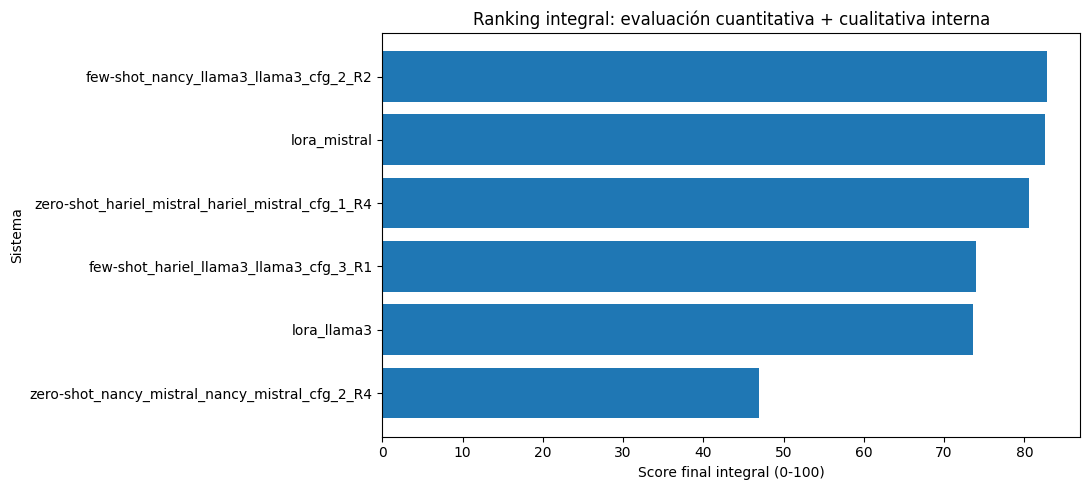

In [32]:
plot_df = integral_df.sort_values("score_final_integral_100", ascending=True)

plt.figure(figsize=(11, 5))
plt.barh(plot_df["system_name"], plot_df["score_final_integral_100"])
plt.xlabel("Score final integral (0-100)")
plt.ylabel("Sistema")
plt.title("Ranking integral: evaluación cuantitativa + cualitativa interna")
plt.tight_layout()
plt.show()

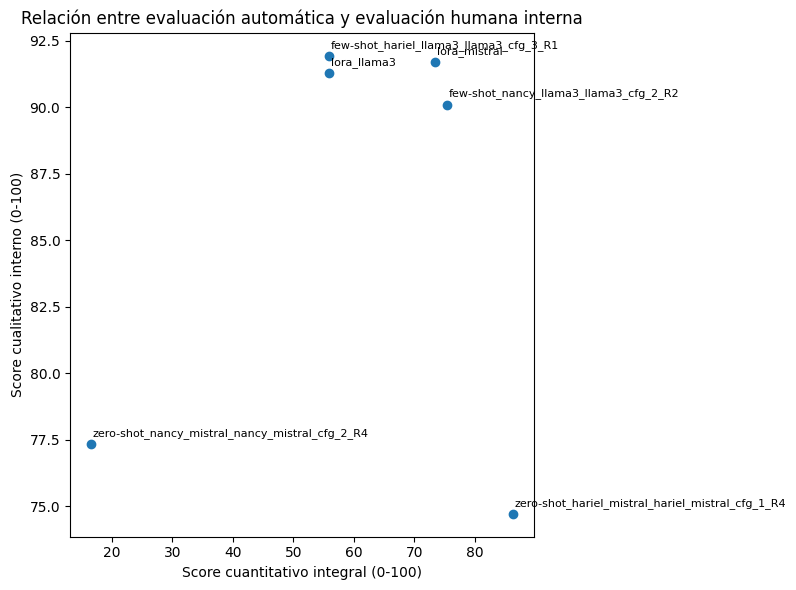

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(
    integral_df["score_cuantitativo_integral_100"],
    integral_df["score_cualitativo_promedio_100"]
)

for _, row in integral_df.iterrows():
    plt.text(
        row["score_cuantitativo_integral_100"] + 0.3,
        row["score_cualitativo_promedio_100"] + 0.3,
        row["system_name"],
        fontsize=8
    )

plt.xlabel("Score cuantitativo integral (0-100)")
plt.ylabel("Score cualitativo interno (0-100)")
plt.title("Relación entre evaluación automática y evaluación humana interna")
plt.tight_layout()
plt.show()

In [34]:
integral_path = OUT_DIR / "ranking_integral_cuantitativo_cualitativo.csv"
reporte_path = OUT_DIR / "tabla_reporte_tt_integral.csv"
detalle_path = OUT_DIR / "detalle_216_cuantitativo_cualitativo.csv"
quant_detail_path = OUT_DIR / "detalle_216_metricas_cuantitativas.csv"
qual_detail_path = OUT_DIR / "detalle_216_cualitativa_interna.csv"
family_path = OUT_DIR / "resumen_por_familia.csv"
excel_path = OUT_DIR / "evaluacion_integral_lora_vs_hiperparametros.xlsx"

integral_df.to_csv(integral_path, index=False, encoding="utf-8-sig")
df_reporte.to_csv(reporte_path, index=False, encoding="utf-8-sig")
detail_df.to_csv(detalle_path, index=False, encoding="utf-8-sig")
df_quant_detail.to_csv(quant_detail_path, index=False, encoding="utf-8-sig")
qual_detail.to_csv(qual_detail_path, index=False, encoding="utf-8-sig")
family_summary.to_csv(family_path, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    df_reporte.to_excel(writer, sheet_name="Ranking reporte TT", index=False)
    integral_df.to_excel(writer, sheet_name="Ranking integral", index=False)
    quant_summary.to_excel(writer, sheet_name="Resumen cuantitativo", index=False)
    qual_summary.to_excel(writer, sheet_name="Resumen cualitativo", index=False)
    comparison_ranks.to_excel(writer, sheet_name="Comparacion rankings", index=False)
    family_summary.to_excel(writer, sheet_name="LoRA vs Prompting", index=False)
    detail_df.to_excel(writer, sheet_name="Detalle 216", index=False)
    df_quant_detail.to_excel(writer, sheet_name="Metricas cuantitativas", index=False)
    qual_detail.to_excel(writer, sheet_name="Cualitativa interna", index=False)

print("Archivos guardados:")
print("-", integral_path)
print("-", reporte_path)
print("-", detalle_path)
print("-", quant_detail_path)
print("-", qual_detail_path)
print("-", family_path)
print("-", excel_path)

Archivos guardados:
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_integral_lora_vs_hiperparametros/ranking_integral_cuantitativo_cualitativo.csv
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_integral_lora_vs_hiperparametros/tabla_reporte_tt_integral.csv
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_integral_lora_vs_hiperparametros/detalle_216_cuantitativo_cualitativo.csv
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_integral_lora_vs_hiperparametros/detalle_216_metricas_cuantitativas.csv
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_integral_lora_vs_hiperparametros/detalle_216_cualitativa_interna.csv
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_integral_lora_vs_hiperparametros/resumen_por_familia.csv
- /home/harielpadillasanchez/Documentos/TT/TT2/outputs/evaluacion_integral_lora_vs_hiperparametros/evaluacion_integral_lora_vs_hiperparametros.xlsx
